In [241]:
import pandas as pd 
import string
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import numpy as np

In [245]:
print(np.arange(0,5))

[0 1 2 3 4]


In [249]:
X = pd.read_csv(r'C:\Users\abiab\Downloads\train.csv.zip')

In [250]:
df = pd.DataFrame(X)
df.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [251]:
data = df.drop(columns = ['id','author','text'])
data.head()

,title,label
0,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",0
2,Why the Truth Might Get You Fired,1
3,15 Civilians Killed In Single US Airstrike Hav...,1
4,Iranian woman jailed for fictional unpublished...,1


In [252]:
data.isnull().sum()

title    558
label      0
dtype: int64

In [253]:
data.dropna(inplace = True)
data.isnull().sum()

title    0
label    0
dtype: int64

In [254]:
data.reset_index(drop = True, inplace= True)

In [255]:
data['length'] = data['title'].apply(len)
data.head()

,title,label,length
0,House Dem Aide: We Didn’t Even See Comey’s Let...,1,81
1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",0,55
2,Why the Truth Might Get You Fired,1,33
3,15 Civilians Killed In Single US Airstrike Hav...,1,63
4,Iranian woman jailed for fictional unpublished...,1,93


In [256]:
data['Type'] = data['title'].apply(type)
data['Type'].value_counts()

Type
<class 'str'>    20242
Name: count, dtype: int64

array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

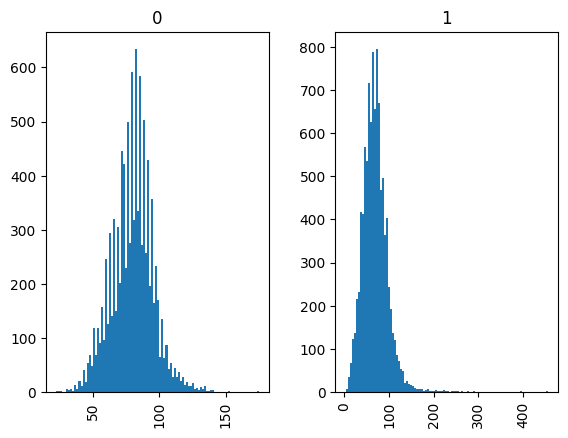

In [257]:
data.hist(column='length', by = 'label', bins = 100)

In [259]:
X = data.iloc[:, :-1]
Y = data.iloc[:, -3]
print(X.shape)
print(Y.shape)

(20242, 3)
(20242,)


In [260]:
Messages = data['title']

<Axes: xlabel='label', ylabel='count'>

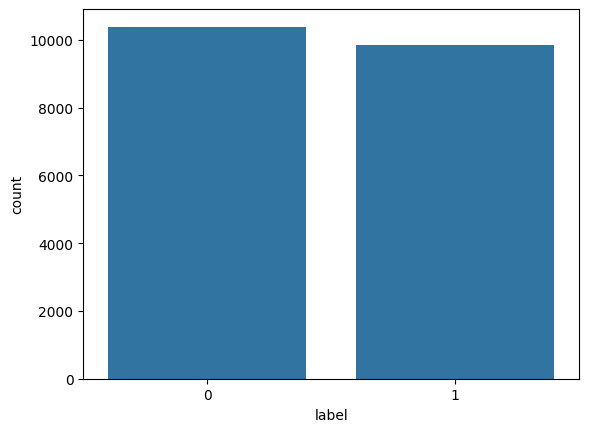

In [261]:
sns.countplot(data=data, x='label')

In [262]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import re
from nltk.tokenize import word_tokenize

lemma = WordNetLemmatizer()
def text_preprocess(Messages):

    processed = []

    for message in Messages:
        words = message.lower()
        words = re.sub('[^a-zA-Z]',' ',words)
        words = word_tokenize(words)
        lemmatized = [lemma.lemmatize(word) for word in words if word not in stopwords.words('english')]
        words = ' '.join(lemmatized) 
        processed.append(words)
    return processed

In [263]:
from tqdm import tqdm

vocab = {'UNK':0}

def build_vocab(text):
    processed_text = text_preprocess(text)
    for message in processed_text:
        tokens = message.split()
        for token in tokens:
            if token not in vocab:
                vocab[token] = len(vocab)
                
build_vocab(Messages[:5])

In [264]:
processed_message = text_preprocess(Messages)

In [265]:
def text_to_indices(vocab, text):
    indexed_seq = []
    if isinstance(text, str):
        text = word_tokenize(text)
    for seq in text:
        tokens = seq.lower()
        tokens = tokens.split()
        index = []
        for token in tokens:
            if token in vocab:
                index.append(vocab[token])
            else:
                index.append(vocab['UNK'])
        indexed_seq.append(index)

    return indexed_seq

In [266]:
print(processed_message[:5])

['house dem aide even see comey letter jason chaffetz tweeted', 'flynn hillary clinton big woman campus breitbart', 'truth might get fired', 'civilian killed single u airstrike identified', 'iranian woman jailed fictional unpublished story woman stoned death adultery']


In [269]:
index_seq = text_to_indices(vocab, processed_message)
print(index_seq[:2])
print(len(index_seq))
print(len(index_seq[0]))

[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [11, 12, 13, 14, 15, 16, 17]]
20242
10


In [270]:
max_length = max(len(seq) for seq in index_seq)
print(max_length)

47


In [271]:
data.describe()

,label,length
count,20242.000000,20242.000000
mean,0.486859,74.319336
std,0.499840,23.161910
min,0.000000,3.000000
25%,0.000000,60.000000
50%,0.000000,75.000000
75%,1.000000,88.000000
max,1.000000,456.000000


In [272]:
data[data['length'] == 456]

,title,label,length,Type
1139,Roger Stone update on Stop the Steal exit poll...,1,456,<class 'str'>


In [273]:
data['label']

0        1
1        0
2        1
3        1
4        1
        ..
20237    0
20238    0
20239    0
20240    1
20241    1
Name: label, Length: 20242, dtype: int64

In [274]:
padded_seq = []

for seq in index_seq:
    padded_seq.append([0] * ((max_length) - len(seq)) + seq)

In [275]:
import torch
from torch.utils.data import Dataset, DataLoader

class dataset(Dataset):
    def __init__(self, vocab, label, df):
        self.seq = df
        self.vocab = vocab
        self.label = label

    def __len__(self):
        return len(self.seq)

    def __getitem__(self, index):
        return torch.tensor(self.seq[index]), torch.tensor(self.label[index])

In [287]:
records = dataset(vocab, data['label'], padded_seq)

In [288]:
from sklearn.model_selection import train_test_split

Messages, X_test, labels, Y_test = train_test_split(records, Y, test_size=0.25, random_state=42)
print(len(Messages))
print(len(labels))
print(len(X_test))
print(len(Y_test))

15181
15181
5061
5061


In [290]:
train_dataloader = DataLoader(Messages, shuffle=True, batch_size=32)
test_dataloader = DataLoader(X_test, shuffle = False, batch_size=32)

In [293]:
for title, labels in train_dataloader:
    print(title, labels)
    print(title.shape)
    print(labels.shape)
    break

print(len(train_dataloader))

tensor([[ 0,  0,  0,  ...,  0,  0,  0],
        [ 0,  0,  0,  ..., 12, 13,  0],
        [ 0,  0,  0,  ..., 12,  0,  0],
        ...,
        [ 0,  0,  0,  ...,  0,  0,  0],
        [ 0,  0,  0,  ...,  0,  0,  0],
        [ 0,  0,  0,  ...,  0,  0, 17]]) tensor([1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 1, 0])
torch.Size([32, 47])
torch.Size([32])
475


In [294]:
for title, labels in test_dataloader:
    print(title, labels)
    print(title.shape)
    print(labels.shape)
    break

print(len(test_dataloader))

tensor([[ 0,  0,  0,  ...,  0,  0,  0],
        [ 0,  0,  0,  ...,  0,  0,  0],
        [ 0,  0,  0,  ...,  0,  0,  0],
        ...,
        [ 0,  0,  0,  ..., 13,  0,  0],
        [ 0,  0,  0,  ...,  0,  0,  0],
        [ 0,  0,  0,  ...,  0, 13,  0]]) tensor([0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1])
torch.Size([32, 47])
torch.Size([32])
159


In [522]:
import torch.nn as nn

class LSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_layer, output_layer):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_layer, batch_first=True)
        self.linear = nn.Linear(hidden_layer, output_layer)

    def forward(self, title):
        embed = self.embedding(title)
        output, (hidden, cell_state) = self.lstm(embed)
        result = self.linear(hidden[-1])
        return result

In [523]:
model = LSTM(len(vocab), 100, 150, 1).to(device)

In [524]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

In [525]:
if torch.cuda.is_available():
    device = torch.device(device='cuda')
else:
    device = torch.device(device='cpu')

In [526]:
total_epoch = 10
train_losses = []

for epoch in range(total_epoch):
    
    total_loss = 0
    
    for i, (title, label) in enumerate(train_dataloader):
        title = title.to(device)
        label = label.to(device).float()  
        
        output = model(title)
        label = label.reshape(-1,1)
        loss = criterion(output, label)

        optimizer.zero_grad()
        loss.backward()  
        optimizer.step()
        
        total_loss += loss.item() 

        if i % 300 == 0:
            print(f"Epoch: {epoch+1}, Batch: {i}, Loss: {loss.item():.5f}")

    avg_loss = total_loss / len(train_dataloader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch + 1} average loss: {avg_loss:.5f}")


Epoch: 1, Batch: 0, Loss: 0.68209
Epoch: 1, Batch: 300, Loss: 0.57340
Epoch 1 average loss: 0.58360
Epoch: 2, Batch: 0, Loss: 0.58477
Epoch: 2, Batch: 300, Loss: 0.56214
Epoch 2 average loss: 0.57059
Epoch: 3, Batch: 0, Loss: 0.57220
Epoch: 3, Batch: 300, Loss: 0.44802
Epoch 3 average loss: 0.56804
Epoch: 4, Batch: 0, Loss: 0.65929
Epoch: 4, Batch: 300, Loss: 0.76198
Epoch 4 average loss: 0.56567
Epoch: 5, Batch: 0, Loss: 0.53305
Epoch: 5, Batch: 300, Loss: 0.47282
Epoch 5 average loss: 0.56473
Epoch: 6, Batch: 0, Loss: 0.54101
Epoch: 6, Batch: 300, Loss: 0.63822
Epoch 6 average loss: 0.56514
Epoch: 7, Batch: 0, Loss: 0.58012
Epoch: 7, Batch: 300, Loss: 0.61193
Epoch 7 average loss: 0.56459
Epoch: 8, Batch: 0, Loss: 0.55251
Epoch: 8, Batch: 300, Loss: 0.64862
Epoch 8 average loss: 0.56376
Epoch: 9, Batch: 0, Loss: 0.49781
Epoch: 9, Batch: 300, Loss: 0.47651
Epoch 9 average loss: 0.56271
Epoch: 10, Batch: 0, Loss: 0.53796
Epoch: 10, Batch: 300, Loss: 0.60632
Epoch 10 average loss: 0.562

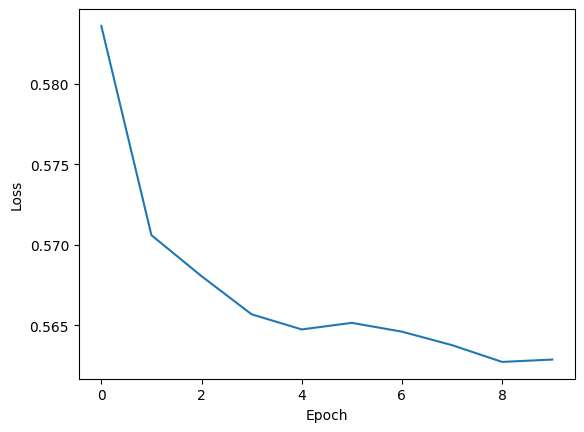

In [527]:
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [529]:
def predict(vocab, title, threshold = 0.5):
    num_question = text_to_indices(vocab, title)
    print(num_question)

    if all(token == vocab['UNK'] for token in num_question):
        print("All tokens are unknown")

    with torch.no_grad():
        question = torch.tensor(num_question).reshape(1,-1)
        print(question)
        output = model(question)
        prob = torch.sigmoid(output).item()
        print(prob)
        if prob >= threshold:
            print("True")
        else:
            print("False")


In [530]:
text = "FLYNN: Hillary Clinton, Big Woman on Campus"
text1 = "Why the Truth Might Get You Fired"
predict(vocab, text1)

[[0], [0], [18], [19], [20], [0], [21]]
tensor([[ 0,  0, 18, 19, 20,  0, 21]])
0.9590035080909729
True


In [531]:
n_correct = 0
n_samples = 0
with torch.no_grad():
    for title, labels in test_dataloader:
        title = title.to(device)
        labels = labels.to(device)

        output = model(title)  
        prob = torch.sigmoid(output).squeeze()
        preds = (prob >= 0.5)
        
        n_samples += labels.shape[0]
        n_correct += (preds == labels).sum().item()
    accuracy = 100 * n_correct / n_samples
    print("accuracy : ", accuracy)
print(n_correct)
print(n_samples)

accuracy :  61.82572614107884
3129
5061
